<div style="background:linear-gradient(135deg,#102a43 0%,#136f63 100%); color:white; padding:28px; border-radius:14px;">
  <div style="font-size:14px; letter-spacing:1.4px; text-transform:uppercase; opacity:.85;">Taller de Programación en Python</div>
  <h1 style="margin:8px 0 4px; color:white;">Clase 6: Costo Computacional y Pensamiento Algorítmico</h1>
  <p style="font-size:18px; margin:8px 0 0;">¿Qué cambia cuando nuestros datos dejan de ser pequeños?</p>
</div>

### Profesor: Lucas Gómez Tobón

## La pregunta de hoy

Ya sabemos usar listas, diccionarios, condicionales, loops y funciones. Ahora aprenderemos a escoger entre distintas maneras de resolver un problema.

> **Dos programas pueden producir exactamente el mismo resultado y tener costos radicalmente diferentes.**

La clase avanza en seis pasos:

1. búsqueda en listas y sets;
2. detección de duplicados mediante hashing;
3. crecimiento del trabajo y problemas intratables;
4. vectorización y procesamiento por lotes;
5. Sliding Window y reutilización de cálculos;

In [43]:
import math
import random
import time
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(2026)

---

## 1. Estructuras de datos: buscar una cédula

Supongamos que tenemos un millón de cédulas y queremos saber si una aparece en la base.

Una lista no tiene un índice para responder esa pregunta. En el peor caso debe recorrer todos sus elementos:

$$
T_{lista}(N) \propto N \qquad \Rightarrow \qquad O(N)
$$

Un `set` usa una **tabla hash** para ubicar directamente la zona donde debería estar una llave:

$$
T_{set}(N) \approx \text{constante} \qquad \Rightarrow \qquad O(1)\text{ en promedio}
$$

```text
LISTA:  [10] → [21] → [35] → ... → [999999]     revisar uno por uno

SET:    hash(999999) → posición probable          saltar a una posición
```

In [44]:
cedulas_lista = list(range(1_000_000))
cedulas_set = set(cedulas_lista)
cedula_buscada = 999_999

### Buscar en la lista

In [45]:
inicio = time.perf_counter()
encontrada = cedula_buscada in cedulas_lista
fin = time.perf_counter()
tiempo_lista = fin - inicio

print("¿Encontrada?", encontrada)
print(f"Tiempo en lista: {(tiempo_lista) * 1_000:.3f} ms")

¿Encontrada? True
Tiempo en lista: 9.077 ms


### Buscar en el set

In [46]:
inicio = time.perf_counter()
encontrada = cedula_buscada in cedulas_set
fin = time.perf_counter()
tiempo_set = fin - inicio

print("¿Encontrada?", encontrada)
print(f"Tiempo en set: {(tiempo_set) * 1_000:.6f} ms")

¿Encontrada? True
Tiempo en set: 0.023625 ms


In [47]:
tiempo_lista/tiempo_set # El set encontrando el valor se demora 314 veces más!

384.2310000121651

> 🔎 **Observar:** medimos únicamente la consulta `in`. El `set` ya estaba construido antes de iniciar el cronómetro. Además, tiempos tan pequeños cambian entre ejecuciones y computadores; nos interesa la diferencia de escala, no un número exacto.

La conclusión no es “use siempre sets”:

| Necesidad | Estructura apropiada |
|---|---|
| conservar orden y repeticiones | `list` |
| consultar muchas veces si una llave existe | `set` |
| asociar cada llave con información | `dict` |

---

## 2. Hashing: encontrar todas las cédulas duplicadas

La misma idea puede transformar un problema completo. Consideremos:

```python
[101, 204, 305, 101, 999, 204, 204]
```

Queremos obtener `{101, 204}`.

### Estrategia 1: comparar todas las parejas

Para cada posición $i$, revisamos todas las posiciones posteriores $j$.

$$
(N-1)+(N-2)+\cdots+1=\frac{N(N-1)}{2}\quad\Rightarrow\quad O(N^2)
$$

In [48]:
def duplicados_fuerza_bruta(cedulas):
    duplicados = set()

    for i in range(len(cedulas)):
        for j in range(i + 1, len(cedulas)):
            if cedulas[i] == cedulas[j]:
                duplicados.add(cedulas[i])

    return duplicados

### Estrategia 2: recordar lo que ya vimos

El hashing cambia la pregunta:

> En vez de preguntar “¿con cuál otra cédula coincide?”, preguntamos “¿ya había visto esta cédula?”.

Solo necesitamos recorrer la lista una vez: $O(N)$.

In [49]:
def duplicados_hash(cedulas):
    vistas = set()
    duplicados = set()

    for cedula in cedulas:
        if cedula in vistas:
            duplicados.add(cedula)
        else:
            vistas.add(cedula)

    return duplicados

In [50]:
cedulas_ejemplo = [101, 204, 305, 101, 999, 204, 204]

print(duplicados_fuerza_bruta(cedulas_ejemplo))
print(duplicados_hash(cedulas_ejemplo))

{204, 101}
{204, 101}


### ¿La diferencia realmente crece?

Construiremos bases cada vez mayores y mediremos ambos algoritmos. La gráfica es parte de la demostración; no es necesario copiar el código de visualización.

In [51]:
tamanos = [500, 1_000, 5_000, 10_000]
tiempos_bruta = []
tiempos_hash = []

for n in tamanos:
    datos = list(range(n)) + [n - 1]
    random.shuffle(datos)

    inicio = time.perf_counter()
    duplicados_fuerza_bruta(datos)
    tiempos_bruta.append(time.perf_counter() - inicio)

    inicio = time.perf_counter()
    duplicados_hash(datos)
    tiempos_hash.append(time.perf_counter() - inicio)

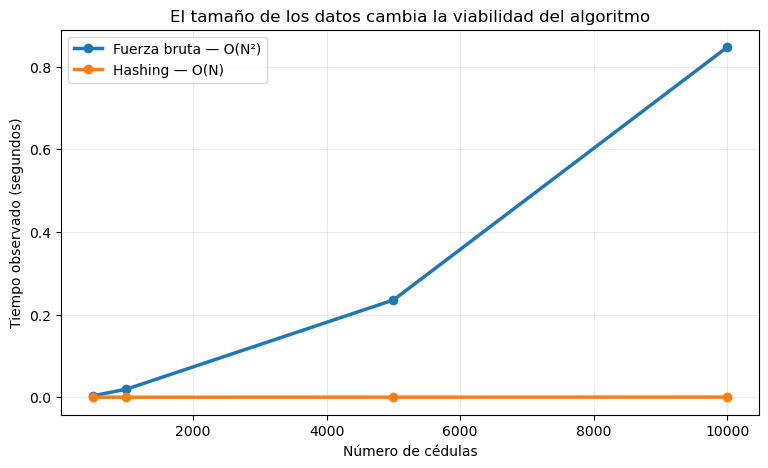

In [52]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tamanos, tiempos_bruta, "o-", linewidth=2.5, label="Fuerza bruta — O(N²)")
ax.plot(tamanos, tiempos_hash, "o-", linewidth=2.5, label="Hashing — O(N)")
ax.set(xlabel="Número de cédulas", ylabel="Tiempo observado (segundos)",
       title="El tamaño de los datos cambia la viabilidad del algoritmo")
ax.grid(alpha=.25)
ax.legend()
plt.show()

> 🔎 **Observar:** ambas versiones funcionan con siete elementos. La diferencia aparece cuando $N$ crece. Big O describe esa trayectoria de crecimiento; no predice los segundos exactos.

---

## 3. Cuando la fuerza bruta deja de ser una opción

En el **Traveling Salesperson Problem (TSP)** buscamos el recorrido más corto que visita todas las ciudades y regresa al origen.

Si fijamos la ciudad inicial y consideramos equivalentes una ruta y su reverso, el número de rutas posibles es:

$$
\frac{(N-1)!}{2}
$$

Este crecimiento no es lineal, cuadrático ni exponencial: es **factorial**.

In [53]:
for ciudades in [10, 20, 30, 60]:
    rutas = math.factorial(ciudades - 1) // 2
    print(f"{ciudades:>2} ciudades: {rutas:.3e} rutas")

rutas_30 = math.factorial(29) // 2
anos = rutas_30 / 1_000_000_000_000 / 60 / 60 / 24 / 365
print()
print(f"30 ciudades a un billón de rutas/segundo: {anos:,.0f} años")

10 ciudades: 1.814e+05 rutas
20 ciudades: 6.082e+16 rutas
30 ciudades: 4.421e+30 rutas
60 ciudades: 6.934e+79 rutas

30 ciudades a un billón de rutas/segundo: 140,185,216,796 años


| Complejidad | Qué ocurre si multiplicamos $N$ por 10 |
|---|---:|
| $O(1)$ | casi no cambia |
| $O(N)$ | aproximadamente $10\times$ |
| $O(N\log N)$ | algo más de $10\times$ |
| $O(N^2)$ | aproximadamente $100\times$ |
| $O(2^N)$ | se multiplica por $1{,}024$ |
| $O(N!)$ | explota factorialmente |

<div style="background:#fff5df; border-left:5px solid #dc8b19; padding:12px 16px; border-radius:6px;">
<b>La pregunta algorítmica:</b> ¿podemos evitar explorar todas las posibilidades, reutilizar trabajo o cambiar la representación del problema?
</div>

---

## 4. Vectorización: hogares y hospitales de Bogotá

Queremos calcular la distancia desde **10.000 hogares** hasta hospitales de Bogotá. Los hogares serán sintéticos, generados alrededor de tres centroides didácticos: norte, centro y sur.

Usaremos coordenadas aproximadas de:

- Hospital Simón Bolívar;
- Hospital Santa Clara;
- Hospital Meissen.

La red geográfica de salud está publicada por la Secretaría Distrital de Salud en [Datos Abiertos Bogotá](https://datosabiertos.bogota.gov.co/dataset/red-adscrita-de-salud-para-bogota).

> Los centroides y hogares son didácticos, no una muestra poblacional.

In [54]:
hogares_norte = np.random.normal([4.72, -74.05], [.02, .025], (3_000, 2))
hogares_centro = np.random.normal([4.65, -74.10], [.02, .025], (3_000, 2))
hogares_sur = np.random.normal([4.58, -74.14], [.02, .025], (4_000, 2))
hogares = np.vstack([hogares_norte, hogares_centro, hogares_sur])

hospitales = np.array([[4.74219, -74.02304], [4.59167, -74.09248], [4.55952, -74.13842]])
nombres = ["Simón Bolívar", "Santa Clara", "Meissen"]

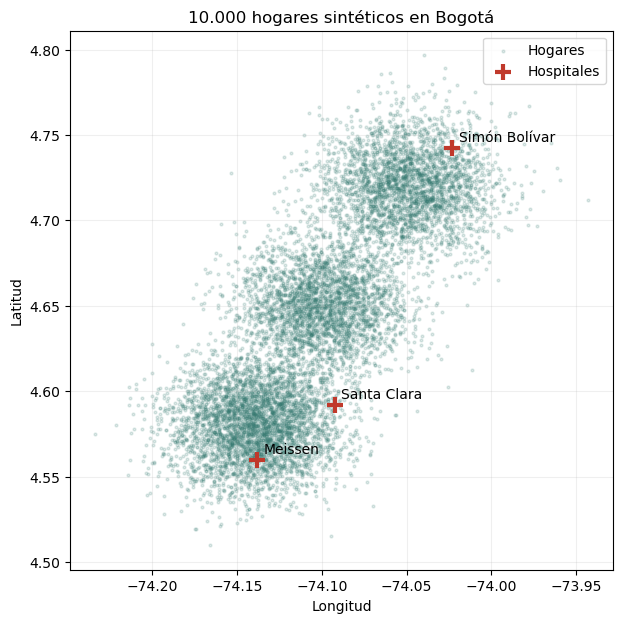

In [55]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(hogares[:, 1], hogares[:, 0], s=4, alpha=.16, color="#357a71", label="Hogares")
ax.scatter(hospitales[:, 1], hospitales[:, 0], s=120, marker="+", linewidth=3, color="#c0392b", label="Hospitales")

for nombre, (lat, lon) in zip(nombres, hospitales):
    ax.annotate(nombre, (lon, lat), xytext=(5, 5), textcoords="offset points")
    
ax.set(xlabel="Longitud", ylabel="Latitud", title="10.000 hogares sintéticos en Bogotá")
ax.legend()
ax.grid(alpha=.2)
plt.show()

### Primero: un hospital y un loop

Para cada hogar calculamos:

$$
d=\sqrt{(x_h-x_c)^2+(y_h-y_c)^2}
$$

La traducción literal usa un loop de Python.

In [59]:
# Calcular la distancia de todos los hogares al hospital 1 (Simón Bolívar)
hospital = hospitales[0]
distancias_loop = []
inicio = time.perf_counter()

for hogar in hogares:
    dx = hogar[0] - hospital[0]
    dy = hogar[1] - hospital[1]
    distancias_loop.append((dx**2 + dy**2)**0.5)

tiempo_loop = time.perf_counter() - inicio
distancias_loop = np.array(distancias_loop)
print(f"Loop: {tiempo_loop:.5f} segundos")

Loop: 0.01480 segundos


### Ahora: la misma operación sobre todo el array

NumPy permite restar el hospital a todas las filas al mismo tiempo. El código expresa directamente la operación matemática.

In [62]:
inicio = time.perf_counter()
diferencias = hogares - hospital
distancias_numpy = np.sqrt(np.sum(diferencias**2, axis=1))
tiempo_numpy = time.perf_counter() - inicio

print(f"NumPy: {tiempo_numpy:.5f} segundos")
print("¿Mismo resultado?", np.allclose(distancias_loop, distancias_numpy))

NumPy: 0.00130 segundos
¿Mismo resultado? True


In [89]:
hospital.shape

(2,)

In [100]:
hospital_fila = hospital[None, :] 
hospital_fila.shape

(1, 2)

In [101]:
# Broadcasting
hospital_fila[[0]*10, :]

array([[  4.55952, -74.13842],
       [  4.55952, -74.13842],
       [  4.55952, -74.13842],
       [  4.55952, -74.13842],
       [  4.55952, -74.13842],
       [  4.55952, -74.13842],
       [  4.55952, -74.13842],
       [  4.55952, -74.13842],
       [  4.55952, -74.13842],
       [  4.55952, -74.13842]])

> 🔎 **Los loops no desaparecen.** En la primera versión, Python interpreta las operaciones de cada hogar. En la segunda, Python entrega arrays completos a NumPy, que recorre los datos mediante código compilado.

Las dos soluciones siguen haciendo trabajo proporcional a $N$: ambas son $O(N)$. La vectorización reduce el costo de ejecutar cada operación, no el número de hogares.

Los términos técnicos son **array operations**, **ufuncs** y **vectorization**. Véase la [documentación de ufuncs de NumPy](https://numpy.org/doc/stable/reference/ufuncs.html).

### Extender la idea a tres hospitales

No necesitamos introducir todavía un array tridimensional. El loop de Python ocurrirá solo **tres veces**; dentro de cada vuelta, NumPy procesa los 10.000 hogares.

In [81]:
matriz_distancias = []

for hospital in hospitales:
    diferencias = hogares - hospital
    distancias = np.sqrt(np.sum(diferencias**2, axis=1))
    matriz_distancias.append(distancias)

matriz_distancias = np.column_stack(matriz_distancias)
hospital_mas_cercano = matriz_distancias.argmin(axis=1)
distancia_mas_cercana = matriz_distancias.min(axis=1)

In [84]:
for i, nombre in enumerate(nombres):
    cantidad = np.sum(hospital_mas_cercano == i)
    print(f"{nombre:14}: {cantidad:,} hogares")

print(f"Distancia media: {distancia_mas_cercana.mean():.2f} km")

Simón Bolívar : 3,147 hogares
Santa Clara   : 3,776 hogares
Meissen       : 3,077 hogares
Distancia media: 0.04 km


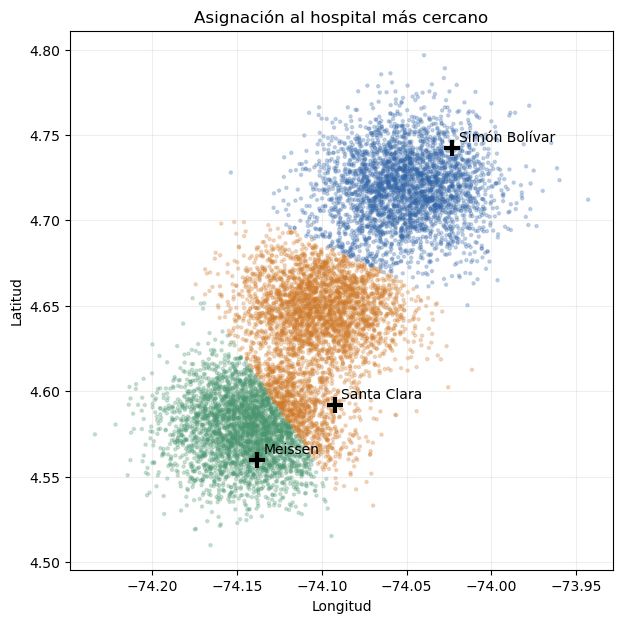

In [85]:
colores = np.array(["#3366a8", "#d07928", "#4a966f"])
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(hogares[:, 1], hogares[:, 0], s=5, alpha=.25,
           c=colores[hospital_mas_cercano])
ax.scatter(hospitales[:, 1], hospitales[:, 0], s=140, marker="+",
           linewidth=3, color="black")
for nombre, (lat, lon) in zip(nombres, hospitales):
    ax.annotate(nombre, (lon, lat), xytext=(5, 5), textcoords="offset points")
ax.set(xlabel="Longitud", ylabel="Latitud", title="Asignación al hospital más cercano")
ax.grid(alpha=.2)
plt.show()

---

## 5. Batching: cuando la matriz completa no cabe en memoria

Con $H$ hogares y $C$ centros, la matriz tiene $HC$ distancias. Si usamos `float64`, solamente esa matriz requiere aproximadamente:

$$
8HC\text{ bytes}
$$

Para un millón de hogares y mil centros son ocho mil millones de bytes (8Gb), sin contar arrays intermedios.

**Batching** o **blocked computation** consiste en procesar grupos pequeños:

```text
hogares 0–1999      → calcular → conservar el mínimo
hogares 2000–3999   → calcular → conservar el mínimo
...
```

Aplica la intuición **dividir–resolver–combinar**, aunque no es el Divide and Conquer recursivo clásico.

In [102]:
tamano_lote = 2_000
hospital_por_lotes = []
distancia_por_lotes = []

for inicio in range(0, len(hogares), tamano_lote):
    lote = hogares[inicio:inicio + tamano_lote]
    distancias_lote = []
    for hospital_km in hospitales:
        diferencias = lote - hospital_km
        distancias = np.sqrt(np.sum(diferencias**2, axis=1))
        distancias_lote.append(distancias)
    distancias_lote = np.column_stack(distancias_lote)
    hospital_por_lotes.extend(distancias_lote.argmin(axis=1))
    distancia_por_lotes.extend(distancias_lote.min(axis=1))

In [103]:
hospital_por_lotes = np.array(hospital_por_lotes)
distancia_por_lotes = np.array(distancia_por_lotes)

print("¿Mismas asignaciones?",
      np.array_equal(hospital_por_lotes, hospital_mas_cercano))
print("¿Mismas distancias?",
      np.allclose(distancia_por_lotes, distancia_mas_cercana))

¿Mismas asignaciones? True
¿Mismas distancias? True


> 🔎 **Observar:** el algoritmo sigue siendo $O(HC)$. Batching no reduce el número total de distancias; limita cuántas conservamos simultáneamente en memoria.

---

## 6. Sliding Window: no calcular dos veces lo mismo

Supongamos que tenemos ventas mensuales y queremos calcular el promedio móvil de tres meses:

```text
ventas = [100, 102, 101, 105, 108, 107]
```

La primera solución toma cada ventana y calcula su suma desde cero.

In [104]:
ventas = [100, 102, 101, 105, 108, 107]
ventana = 3
promedios_recalculados = []

for i in range(len(ventas) - ventana + 1):
    bloque = ventas[i:i + ventana]
    promedio = sum(bloque) / ventana
    promedios_recalculados.append(promedio)

print(promedios_recalculados)

[101.0, 102.66666666666667, 104.66666666666667, 106.66666666666667]


### ¿Qué estamos repitiendo?

Dos ventanas consecutivas comparten casi todos sus datos:

```text
[100, 102, 101] 105, 108, 107
       ↓ mover una posición
 100, [102, 101, 105] 108, 107

       sale 100  ← suma anterior →  entra 105
```

Podemos conservar la suma anterior, restar el valor que sale y agregar el que entra. Este patrón clásico se llama **Sliding Window**.

In [105]:
suma = sum(ventas[:ventana])
promedios_sliding = [suma / ventana]

for i in range(ventana, len(ventas)):
    sale = ventas[i - ventana]
    entra = ventas[i]
    suma = suma - sale + entra
    promedios_sliding.append(suma / ventana)

print(promedios_sliding)

[101.0, 102.66666666666667, 104.66666666666667, 106.66666666666667]


> 🔎 **Observar:** no inventamos una fórmula distinta para el promedio. Cambiamos la forma de organizar el trabajo.

| Estrategia | Costo para $N$ datos y ventana $K$ |
|---|---:|
| volver a sumar cada ventana | $O(NK)$ |
| actualizar la suma anterior | $O(N)$ |

Sliding Window mantiene solamente una suma: $O(1)$ de estado adicional. La lista de resultados sí ocupa $O(N)$ porque decidimos conservar todos los promedios.

Esta idea prepara el siguiente tema: **cuando un resultado comparte trabajo con resultados anteriores, buscamos cómo reutilizarlo**.

---

## Resumen: seis transformaciones

| Problema observado | Concepto clásico | Idea fundamental |
|---|---|---|
| muchas búsquedas en las mismas llaves | Hash Table | escoger una estructura con lookup apropiado |
| comparar todos contra todos | Hashing | recordar lo que ya vimos |
| muchos cálculos numéricos iguales | Vectorization | operar sobre arrays completos |
| arrays intermedios demasiado grandes | Batching / Blocked Computation | controlar la memoria por bloques |
| ventanas consecutivas comparten datos | Sliding Window | actualizar solo lo que cambió |
| muchas trayectorias llegan al mismo estado | Dynamic Programming | resolver cada estado una sola vez |

### Las preguntas que queremos llevarnos

1. ¿Qué parte del trabajo se repite?
2. ¿Cómo crece ese trabajo cuando crece el input?
3. ¿Qué información vale la pena recordar?
4. ¿Podemos cambiar la estructura de datos o la representación?
5. ¿La restricción real es tiempo, memoria o exactitud?

---

## 🎁 Bono: Climbing Stairs

Una escalera tiene $N$ peldaños. En cada movimiento puede subir **uno o dos peldaños**.

> **¿De cuántas maneras diferentes puede llegar exactamente al peldaño $N$?**

Algunos casos pequeños:

| $N$ | Número de maneras |
|---:|---:|
| 1 | 1 |
| 2 | 2 |
| 3 | 3 |

Antes de programar, discuta:

1. ¿Cuál sería el **estado**?
2. ¿Cuáles son los **casos base**?
3. ¿Qué subproblemas se repiten?
4. ¿Cómo construiría la respuesta para $N$ usando respuestas anteriores?
5. ¿Preferiría **memoization** o **tabulation**?

✍️ **Resuelva el problema usando Dynamic Programming en la siguiente celda.**